# Predicting the Future — EDA Notebook

**DS-GA 1003 · NYU · Dhairya Dhamani, Hector Thompson Baroni, Sachin Sastri**

Exploratory data analysis of the Polymarket snapshot dataset.  
Covers data quality, feature distributions, the market-price baseline, and lifecycle analysis.

## 1  Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

ROOT     = Path("..")
DATA_DIR = ROOT / "data"

ROLLING_7D  = ["price_mean_7d","price_volatility_7d","price_min_7d",
                "price_max_7d","price_change_7d","price_range_7d","price_trend_7d"]
ROLLING_14D = [c.replace("_7d","_14d") for c in ROLLING_7D]

In [2]:
meta = pd.read_csv(DATA_DIR / "polymarket_markets_meta.csv")
meta["start_date"] = pd.to_datetime(meta["start_date"], format="ISO8601", utc=True)
meta["end_date"]   = pd.to_datetime(meta["end_date"],   format="ISO8601", utc=True)

df = pd.read_parquet(DATA_DIR / "polymarket_ml_dataset.parquet")

print(f"Meta:    {meta.shape[0]:,} rows × {meta.shape[1]} cols")
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")

Meta:    24,092 rows × 11 cols
Dataset: 4,078,109 rows × 27 cols


## 2  Market Metadata

### 2.1  Basic info

In [3]:
meta.head(3)

,market_id,clob_token_id,question,category,start_date,end_date,duration_days,total_volume,yes_final_price,outcome,split
0,0x36ffdcaa4ea814d2b83f9cc68c4ac40b8eda9dc7317a...,8765628745397802521321715121612411170490623103...,Will Toumani Camara lead the NBA in steals dur...,NaN,2025-10-22 05:32:15.878458+00:00,2026-04-12 00:00:00+00:00,171,17182.003979,0.0,0,train
1,0x1bfc5eb86ade981f6722e91bc07f6a0bd398e906cb2f...,2849854327242689812110996567528468507308758296...,Will Never Too Late (Elton John and Brandi Car...,NaN,2025-10-08 23:19:55.340490+00:00,2026-02-01 00:00:00+00:00,115,39356.220000,0.0,0,train
2,0xf0e959938500e2243dc604c8a2caf9cae03dd7710301...,7952830480116302423617734963224849651965577913...,Will Ollie Gordon II record the most rushing y...,NaN,2025-05-13 21:08:38.087920+00:00,2026-01-18 12:00:00+00:00,249,10757.819565,0.0,0,train


In [4]:
meta.dtypes

market_id                       object
clob_token_id                   object
question                        object
category                        object
start_date         datetime64[ns, UTC]
end_date           datetime64[ns, UTC]
duration_days                    int64
total_volume                   float64
yes_final_price                float64
outcome                          int64
split                           object
dtype: object

In [5]:
meta.isnull().sum()[meta.isnull().sum() > 0]

category    24075
dtype: int64

### 2.2  Outcome distribution

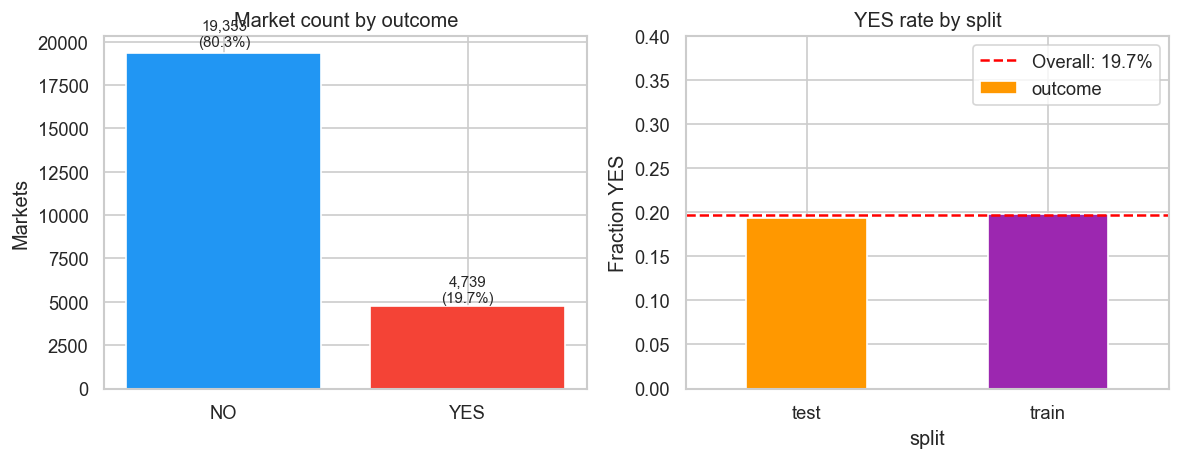

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Counts
counts = meta["outcome"].map({1: "YES", 0: "NO"}).value_counts()
colors = ["#2196F3", "#F44336"]
axes[0].bar(counts.index, counts.values, color=colors)
for bar, v in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f"{v:,}\n({v/len(meta):.1%})", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Market count by outcome")
axes[0].set_ylabel("Markets")

# By split
split_outcome = meta.groupby("split")["outcome"].mean()
split_outcome.plot(kind="bar", ax=axes[1], color=["#FF9800","#9C27B0"], rot=0)
axes[1].set_title("YES rate by split")
axes[1].set_ylabel("Fraction YES")
axes[1].set_ylim(0, 0.4)
axes[1].axhline(meta["outcome"].mean(), color="red", linestyle="--", label=f"Overall: {meta['outcome'].mean():.1%}")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.3  Duration distribution

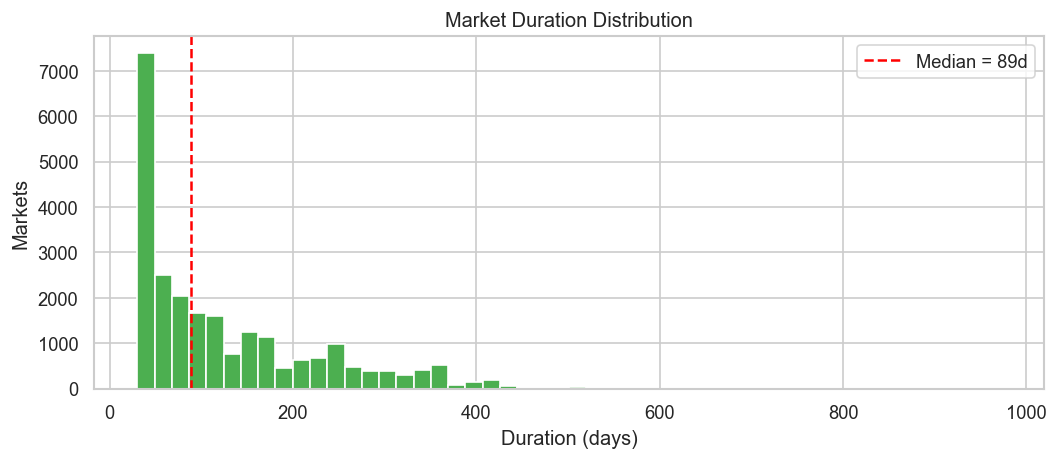

count    24092.0
mean       125.4
std        102.5
min         30.0
25%         42.0
50%         89.0
75%        174.0
max        972.0
Name: duration_days, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(meta["duration_days"], bins=50, color="#4CAF50", edgecolor="white")
ax.axvline(meta["duration_days"].median(), color="red", linestyle="--",
           label=f"Median = {meta['duration_days'].median():.0f}d")
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Markets")
ax.set_title("Market Duration Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(meta["duration_days"].describe().round(1))

### 2.4  Volume distribution

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/var/folders/xw/fqgz8zys6kbgzg3rlxjygz8c0000gn/T/ipykernel_29803/180208116.py:5: SyntaxWarning: invalid escape sequence '\$'
  label=f"Median = \${meta['total_volume'].median():,.0f}")


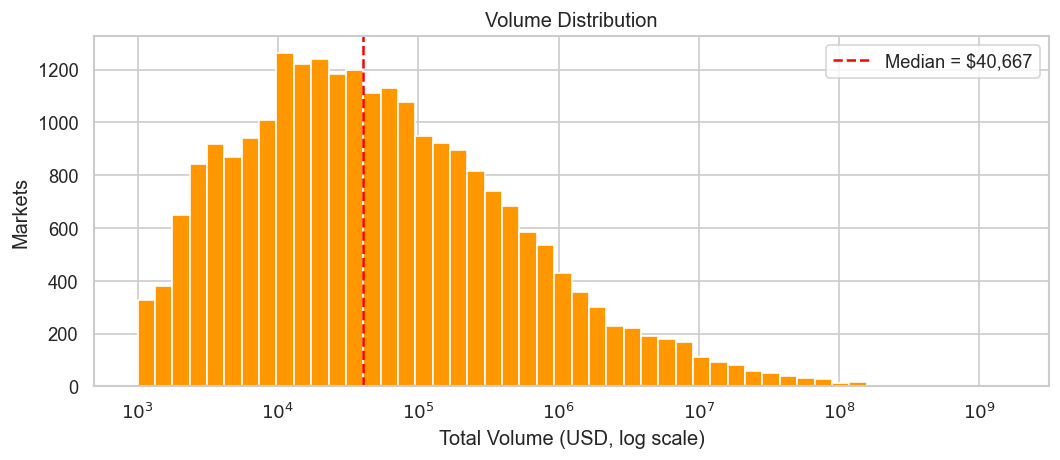

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
log_vol = np.log10(meta["total_volume"].clip(lower=1))
ax.hist(log_vol, bins=50, color="#FF9800", edgecolor="white")
ax.axvline(np.log10(meta["total_volume"].median()), color="red", linestyle="--",
           label=f"Median = \${meta['total_volume'].median():,.0f}")
ticks = [3, 4, 5, 6, 7, 8, 9]
ax.set_xticks(ticks)
ax.set_xticklabels([f"$10^{{{t}}}$" for t in ticks])
ax.set_xlabel("Total Volume (USD, log scale)")
ax.set_ylabel("Markets")
ax.set_title("Volume Distribution")
ax.legend()
plt.tight_layout()
plt.show()

### 2.5  Date range

Earliest start: 2020-10-02
Latest start:   2026-02-06


/var/folders/xw/fqgz8zys6kbgzg3rlxjygz8c0000gn/T/ipykernel_29803/3403910553.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  meta["year_month"] = meta["start_date"].dt.to_period("M")


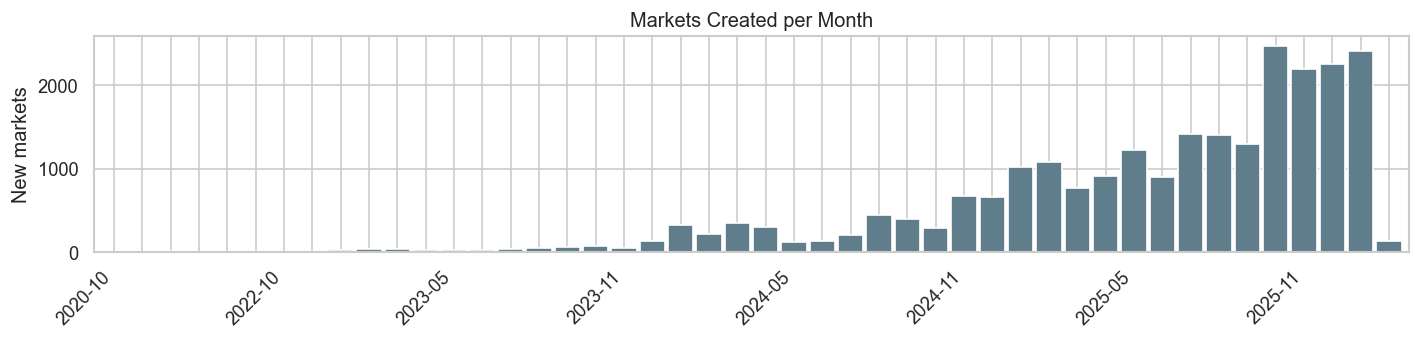

In [9]:
print(f"Earliest start: {meta['start_date'].min().date()}")
print(f"Latest start:   {meta['start_date'].max().date()}")

# Markets created per month
meta["year_month"] = meta["start_date"].dt.to_period("M")
monthly = meta.groupby("year_month").size()

fig, ax = plt.subplots(figsize=(12, 3))
monthly.plot(kind="bar", ax=ax, color="#607D8B", width=0.9)
ax.set_xlabel("")
ax.set_ylabel("New markets")
ax.set_title("Markets Created per Month")
ax.set_xticklabels([str(p) if i % 6 == 0 else "" for i, p in enumerate(monthly.index)], rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3  Snapshot Dataset

### 3.1  Missing values

In [10]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print(nulls.to_string())

category    4067426


In [11]:
# NaN rolling features are expected in early lifecycle — confirm
ROLLING_7D  = ["price_mean_7d","price_volatility_7d","price_min_7d",
                "price_max_7d","price_change_7d","price_range_7d","price_trend_7d"]

nan_mask = df[ROLLING_7D].isna().any(axis=1)
print(f"Snapshots with NaN 7d features: {nan_mask.sum():,} ({nan_mask.mean():.1%})")
print(f"Markets  with NaN 7d features:  {df[nan_mask]['market_id'].nunique():,}")

Snapshots with NaN 7d features: 0 (0.0%)
Markets  with NaN 7d features:  0


### 3.2  Snapshots per market

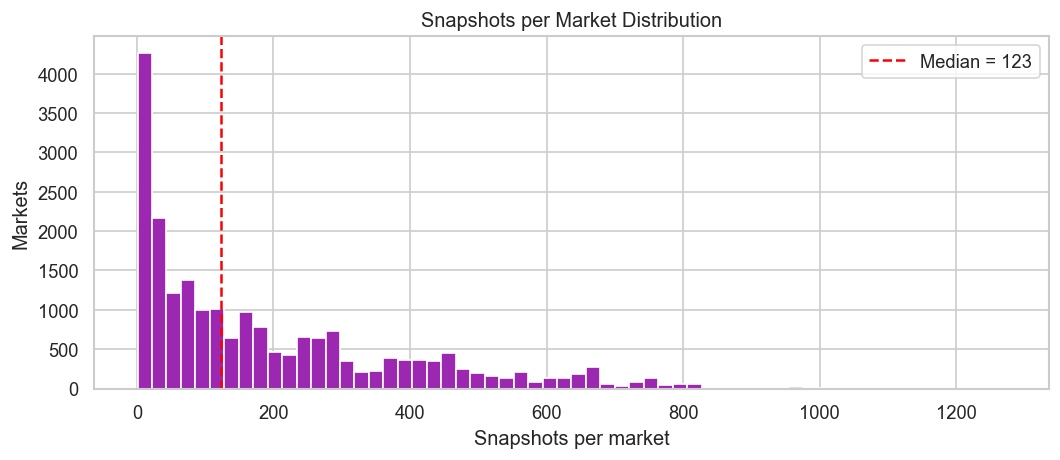

count    21316.0
mean       191.3
std        197.1
min          1.0
25%         31.0
50%        123.0
75%        288.0
max       1272.0
dtype: float64


In [12]:
snaps_per = df.groupby("market_id").size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(snaps_per.values, bins=60, color="#9C27B0", edgecolor="white")
ax.axvline(snaps_per.median(), color="red", linestyle="--", label=f"Median = {snaps_per.median():.0f}")
ax.set_xlabel("Snapshots per market")
ax.set_ylabel("Markets")
ax.set_title("Snapshots per Market Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(snaps_per.describe().round(1))

## 4  Price Features

### 4.1  Price at snapshot by outcome

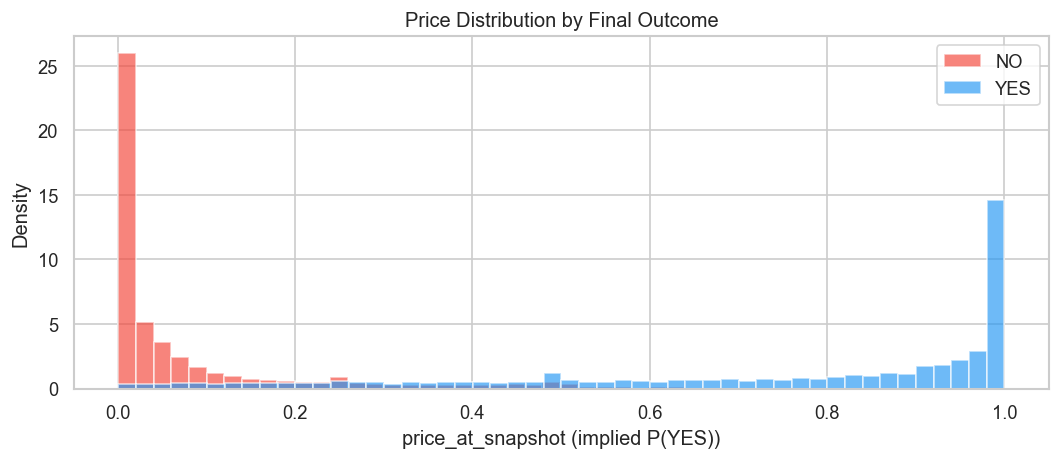

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
prices = df["price_at_snapshot"].clip(0, 1)
for outcome_val, label, color in [(0, "NO", "#F44336"), (1, "YES", "#2196F3")]:
    ax.hist(prices[df["outcome"] == outcome_val], bins=50,
            alpha=0.65, label=label, color=color, density=True)
ax.set_xlabel("price_at_snapshot (implied P(YES))")
ax.set_ylabel("Density")
ax.set_title("Price Distribution by Final Outcome")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2  Rolling feature distributions

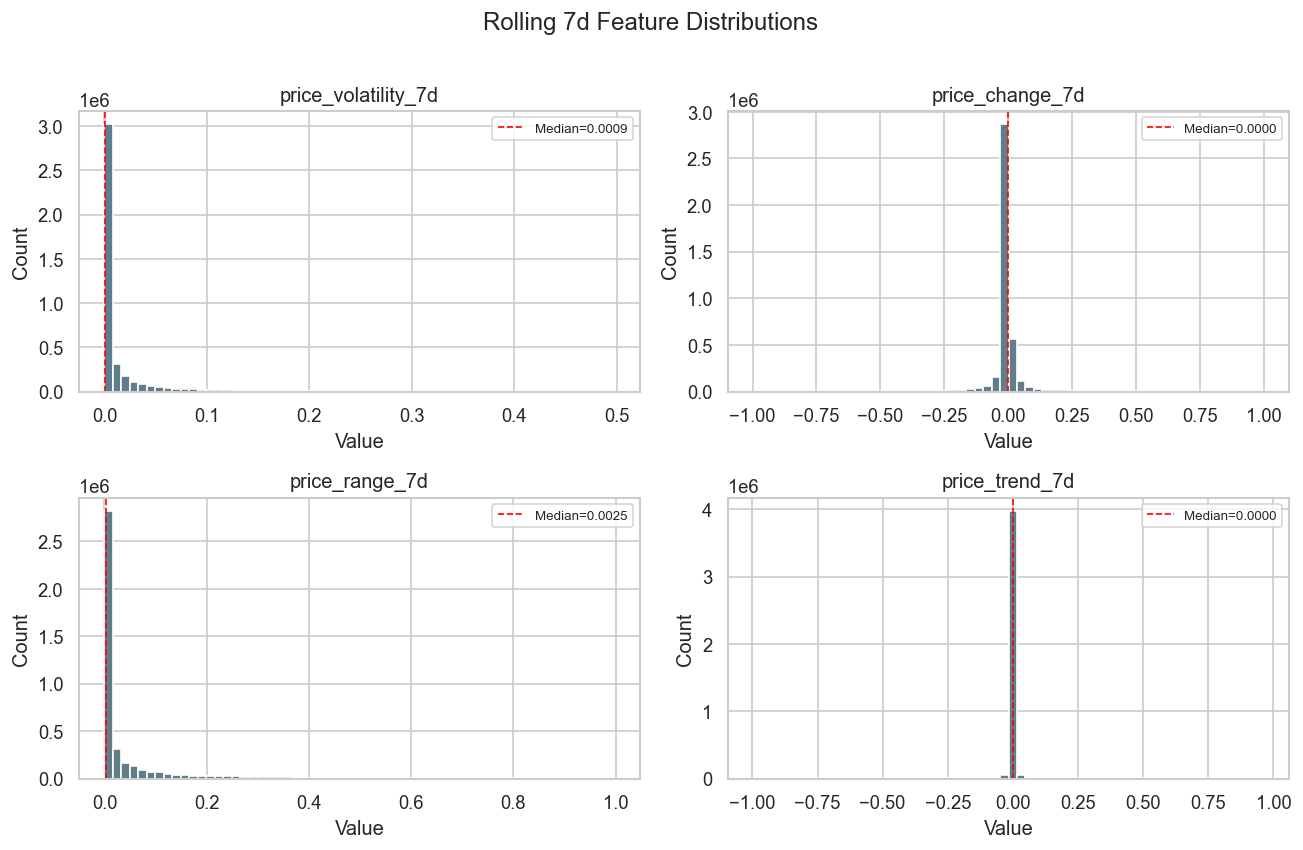

In [14]:
features = ["price_volatility_7d", "price_change_7d", "price_range_7d", "price_trend_7d"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for ax, col in zip(axes, features):
    data = df[col].dropna()
    ax.hist(data, bins=60, color="#607D8B", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1,
               label=f"Median={data.median():.4f}")
    ax.legend(fontsize=8)

plt.suptitle("Rolling 7d Feature Distributions", y=1.01)
plt.tight_layout()
plt.show()

### 4.3  NaN rate by lifecycle stage

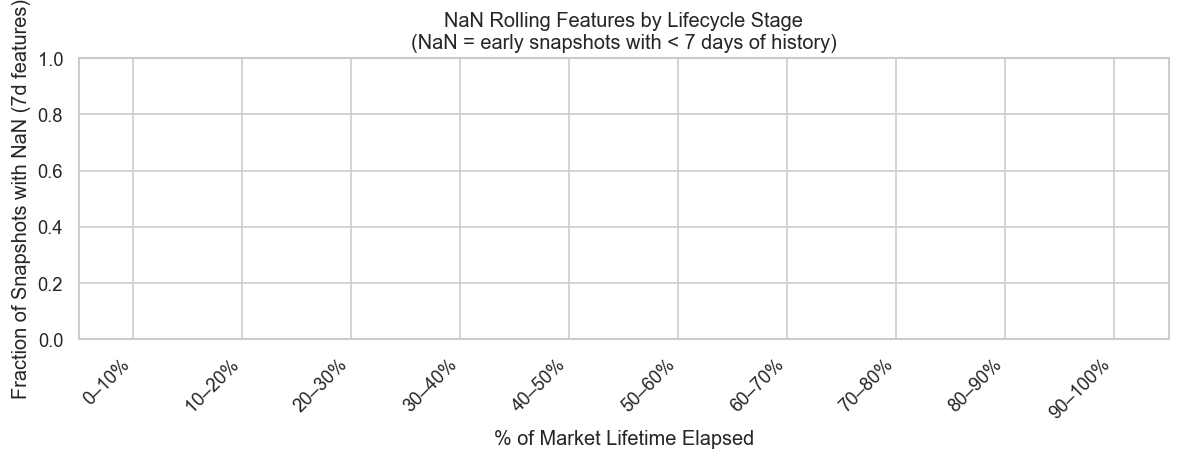

In [15]:
tmp = df[["pct_lifetime_elapsed", "price_mean_7d"]].copy()
tmp["pct_bucket"] = pd.cut(tmp["pct_lifetime_elapsed"], bins=10,
                            labels=[f"{i*10}–{(i+1)*10}%" for i in range(10)])
nan_frac = tmp.groupby("pct_bucket", observed=True)["price_mean_7d"].apply(lambda x: x.isna().mean())

fig, ax = plt.subplots(figsize=(10, 4))
nan_frac.plot(kind="bar", ax=ax, color="#FF5722", edgecolor="white")
ax.set_xlabel("% of Market Lifetime Elapsed")
ax.set_ylabel("Fraction of Snapshots with NaN (7d features)")
ax.set_title("NaN Rolling Features by Lifecycle Stage\n(NaN = early snapshots with < 7 days of history)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5  Feature Correlations

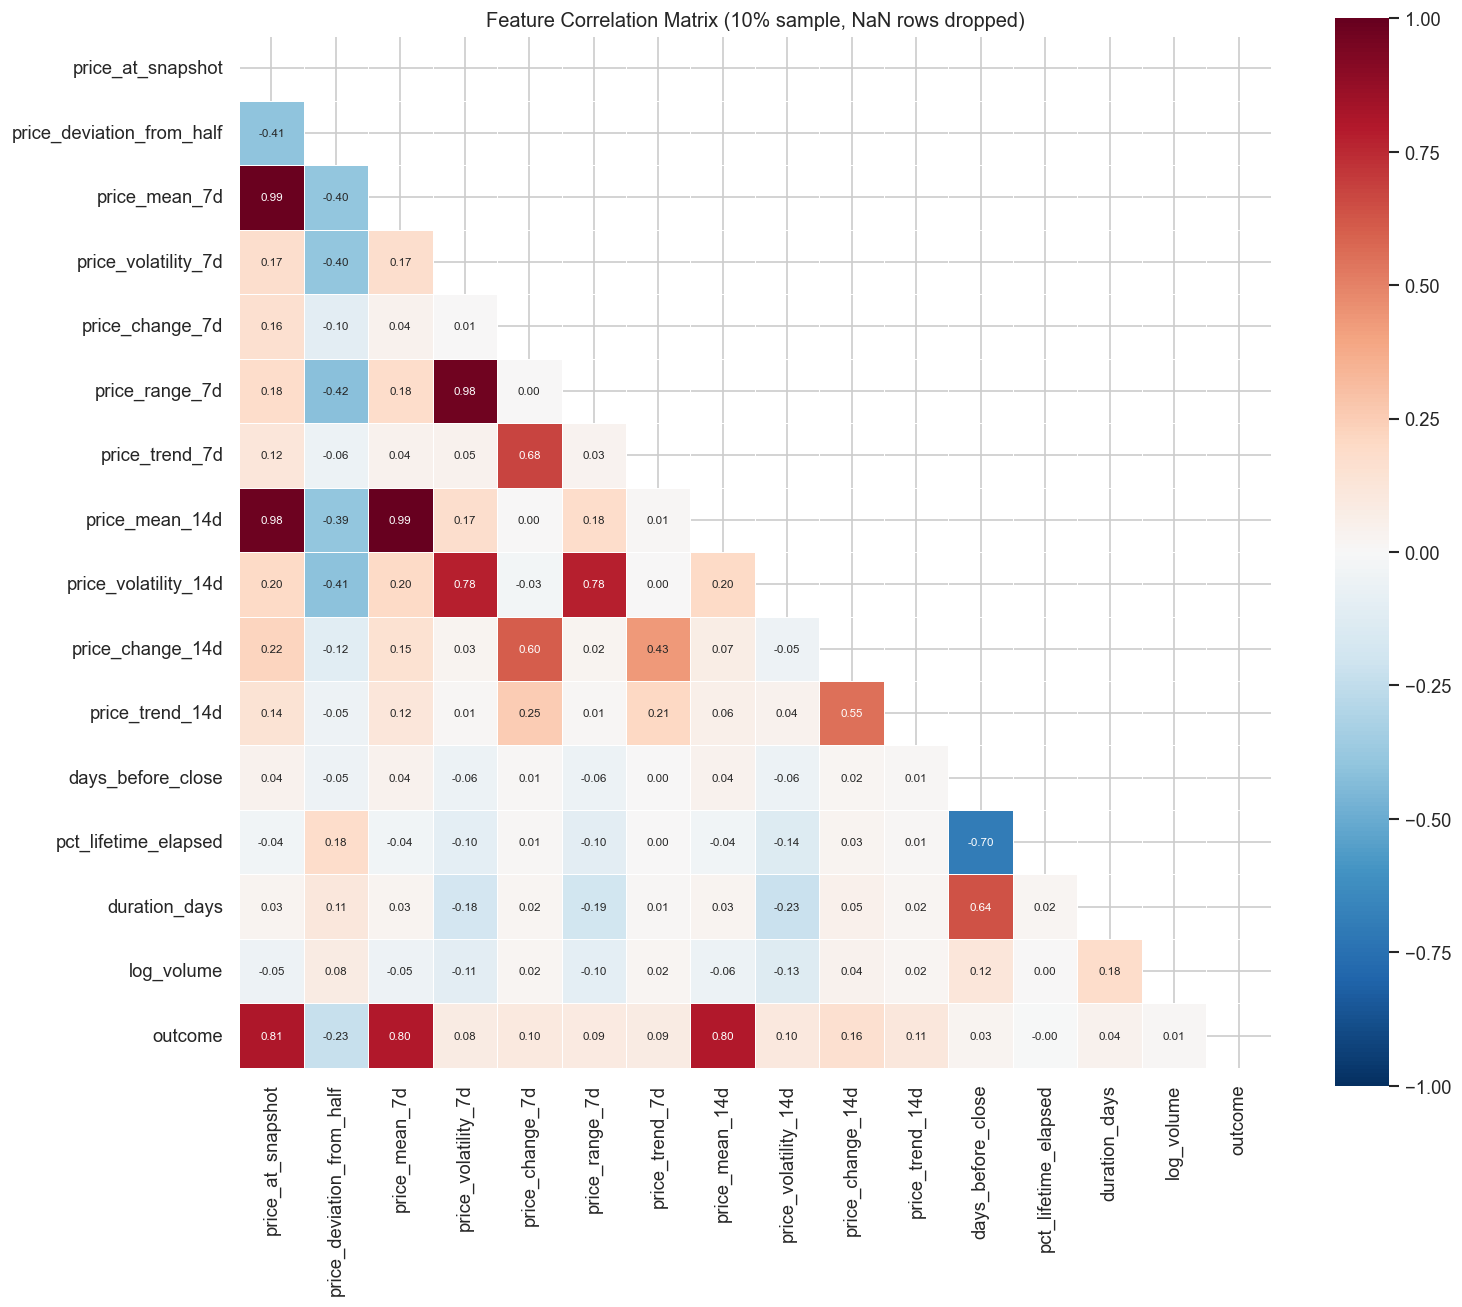

In [16]:
feature_cols = [
    "price_at_snapshot", "price_deviation_from_half",
    "price_mean_7d", "price_volatility_7d", "price_change_7d",
    "price_range_7d", "price_trend_7d",
    "price_mean_14d", "price_volatility_14d", "price_change_14d",
    "price_trend_14d",
    "days_before_close", "pct_lifetime_elapsed",
    "duration_days", "log_volume",
    "outcome",
]

# Use a 10% sample to keep it fast
sample = df[feature_cols].dropna().sample(frac=0.1, random_state=42)
corr = sample.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Feature Correlation Matrix (10% sample, NaN rows dropped)")
plt.tight_layout()
plt.show()

In [17]:
# Correlation with outcome only
corr_outcome = sample.corr()["outcome"].drop("outcome").sort_values(key=abs, ascending=False)
print("Correlations with outcome (sorted by |r|):")
print(corr_outcome.round(4).to_string())

Correlations with outcome (sorted by |r|):
price_at_snapshot            0.8066
price_mean_7d                0.8035
price_mean_14d               0.7977
price_deviation_from_half   -0.2334
price_change_14d             0.1598
price_trend_14d              0.1127
price_volatility_14d         0.1037
price_change_7d              0.1011
price_range_7d               0.0905
price_trend_7d               0.0856
price_volatility_7d          0.0839
duration_days                0.0391
days_before_close            0.0299
log_volume                   0.0118
pct_lifetime_elapsed        -0.0030


## 6  Market Price Calibration (RQ1 Baseline)

The market price `price_at_snapshot` is the key baseline.  
If the market is perfectly calibrated, a price of 0.7 should mean the event resolves YES 70% of the time.  
AUC-ROC and log-loss measure how good the market price is as a probabilistic predictor.

In [18]:
train = df[df["split"] == "train"].copy()
train["price_at_snapshot"] = train["price_at_snapshot"].clip(0, 1)

y_true  = train["outcome"].values
y_score = train["price_at_snapshot"].values
y_pred  = (y_score > 0.5).astype(int)

print(f"Baseline (price_at_snapshot, TRAIN only)")
print(f"  Accuracy (threshold=0.5): {accuracy_score(y_true, y_pred):.4f}")
print(f"  AUC-ROC:                  {roc_auc_score(y_true, y_score):.4f}")
print(f"  Log-loss:                 {log_loss(y_true, y_score):.4f}")

Baseline (price_at_snapshot, TRAIN only)
  Accuracy (threshold=0.5): 0.9379
  AUC-ROC:                  0.9640
  Log-loss:                 0.1713


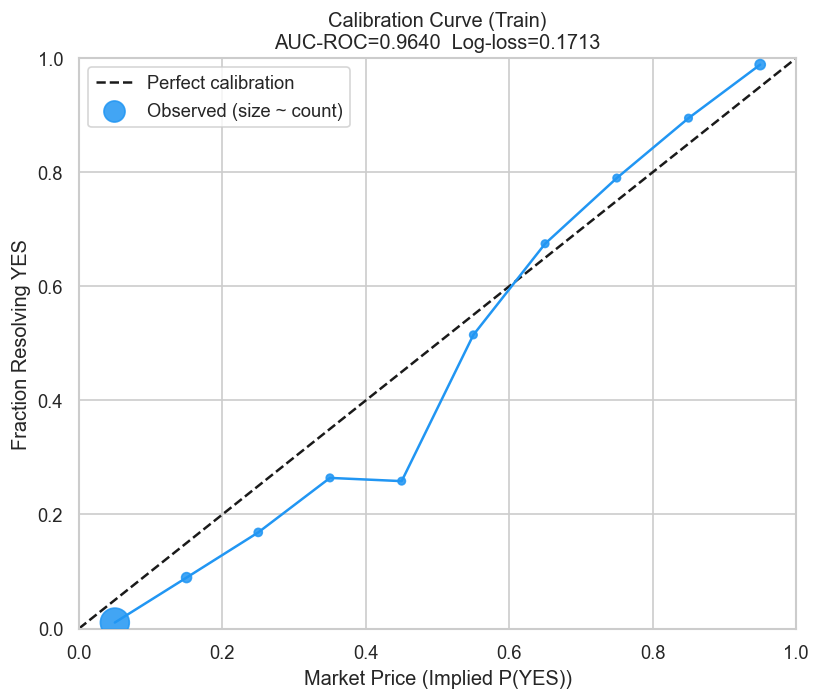


Calibration table:
price_bin  frac_yes   count
  0.0–0.1  0.010451 2122967
  0.1–0.2  0.089256  249564
  0.2–0.3  0.168503  165279
  0.3–0.4  0.264076   99869
  0.4–0.5  0.258417  138381
  0.5–0.6  0.514852   61707
  0.6–0.7  0.674670   54729
  0.7–0.8  0.789823   52884
  0.8–0.9  0.894872   63104
  0.9–1.0  0.988741  260061


In [19]:
# Calibration curve
bins   = np.linspace(0, 1, 11)
labels = [f"{bins[i]:.1f}–{bins[i+1]:.1f}" for i in range(10)]
train["price_bin"] = pd.cut(train["price_at_snapshot"], bins=bins,
                             labels=labels, include_lowest=True)
cal = (train.groupby("price_bin", observed=True)
       .agg(frac_yes=("outcome","mean"), count=("outcome","size"))
       .reset_index())

bin_centers = (bins[:-1] + bins[1:]) / 2
auc = roc_auc_score(y_true, y_score)
ll  = log_loss(y_true, y_score)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],"k--",linewidth=1.5, label="Perfect calibration")
ax.plot(bin_centers, cal["frac_yes"].values, color="#2196F3", linewidth=1.5)
size = np.maximum(cal["count"].values / cal["count"].max() * 300, 20)
ax.scatter(bin_centers, cal["frac_yes"].values, s=size, color="#2196F3",
           alpha=0.85, label="Observed (size ~ count)", zorder=5)
ax.set_xlabel("Market Price (Implied P(YES))")
ax.set_ylabel("Fraction Resolving YES")
ax.set_title(f"Calibration Curve (Train)\nAUC-ROC={auc:.4f}  Log-loss={ll:.4f}")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.legend()
plt.tight_layout()
plt.show()

print("\nCalibration table:")
print(cal.to_string(index=False))

## 7  Lifecycle Analysis (RQ3)

Does the value of external signals change across a market's lifetime?  
We split snapshots into lifecycle buckets and measure AUC of the market price alone at each stage.

In [20]:
train_clean = train.dropna(subset=["price_at_snapshot","outcome"])
train_clean = train_clean.copy()
train_clean["pct_bucket"] = pd.cut(
    train_clean["pct_lifetime_elapsed"], bins=5,
    labels=["0–20%","20–40%","40–60%","60–80%","80–100%"]
)

results = []
for bucket, grp in train_clean.groupby("pct_bucket", observed=True):
    if len(grp) < 100:
        continue
    auc = roc_auc_score(grp["outcome"], grp["price_at_snapshot"])
    acc = accuracy_score(grp["outcome"], (grp["price_at_snapshot"] > 0.5).astype(int))
    results.append({"bucket": bucket, "auc": auc, "accuracy": acc, "n": len(grp)})

lc = pd.DataFrame(results)
print(lc.to_string(index=False))

 bucket      auc  accuracy      n
  0–20% 0.927998  0.911742 485608
 20–40% 0.944417  0.922780 743922
 40–60% 0.961803  0.936972 805067
 60–80% 0.978227  0.952158 754046
80–100% 0.990923  0.967195 479902


/var/folders/xw/fqgz8zys6kbgzg3rlxjygz8c0000gn/T/ipykernel_29803/3232956883.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(lc["bucket"].astype(str), rotation=30, ha="right")
/var/folders/xw/fqgz8zys6kbgzg3rlxjygz8c0000gn/T/ipykernel_29803/3232956883.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(lc["bucket"].astype(str), rotation=30, ha="right")


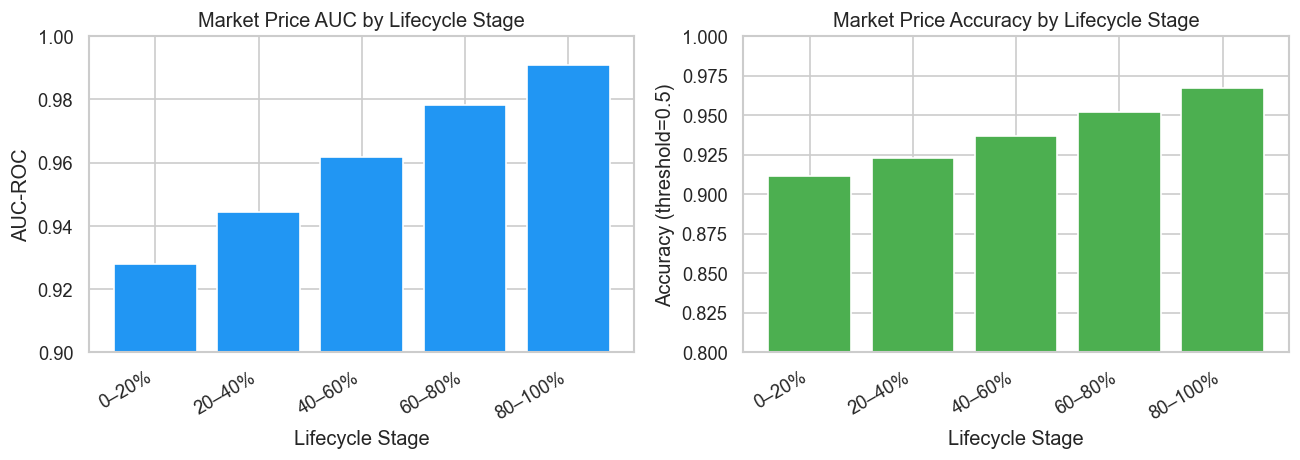

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(lc["bucket"].astype(str), lc["auc"], color="#2196F3", edgecolor="white")
axes[0].set_ylim(0.9, 1.0)
axes[0].set_xlabel("Lifecycle Stage")
axes[0].set_ylabel("AUC-ROC")
axes[0].set_title("Market Price AUC by Lifecycle Stage")
axes[0].set_xticklabels(lc["bucket"].astype(str), rotation=30, ha="right")

axes[1].bar(lc["bucket"].astype(str), lc["accuracy"], color="#4CAF50", edgecolor="white")
axes[1].set_ylim(0.8, 1.0)
axes[1].set_xlabel("Lifecycle Stage")
axes[1].set_ylabel("Accuracy (threshold=0.5)")
axes[1].set_title("Market Price Accuracy by Lifecycle Stage")
axes[1].set_xticklabels(lc["bucket"].astype(str), rotation=30, ha="right")

plt.tight_layout()
plt.show()

**Observation:** AUC rises as the market approaches resolution — the market price becomes a stronger predictor later in the lifecycle. This means external signals (momentum, volatility) are most likely to add value **early in the lifecycle**.

### 7.1  AUC by days before close

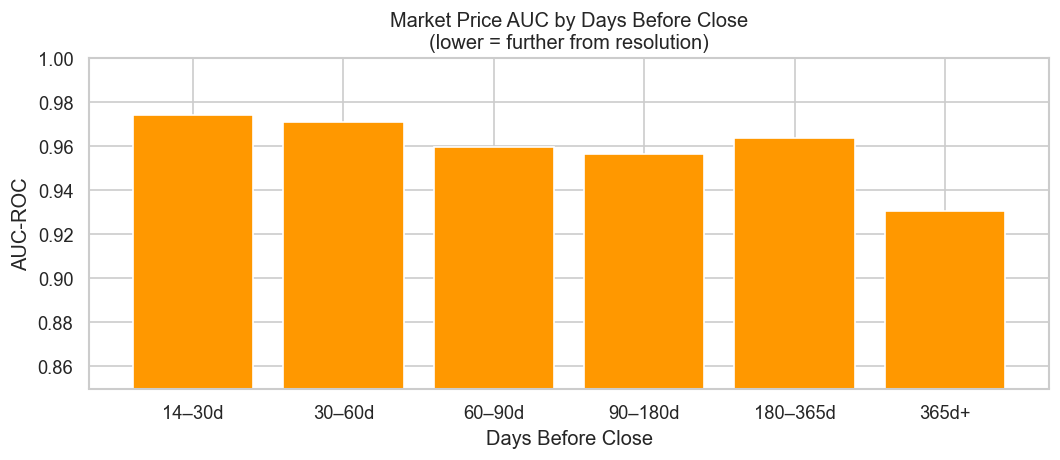

  bucket      auc      n
  14–30d 0.974101 473104
  30–60d 0.970978 664407
  60–90d 0.959845 512090
 90–180d 0.956548 961403
180–365d 0.963747 622639
   365d+ 0.930589  34831


In [22]:
bins_dbc = [14, 30, 60, 90, 180, 365, 9999]
labels_dbc = ["14–30d","30–60d","60–90d","90–180d","180–365d","365d+"]
train_clean["dbc_bucket"] = pd.cut(train_clean["days_before_close"],
                                    bins=bins_dbc, labels=labels_dbc)

dbc_results = []
for bucket, grp in train_clean.groupby("dbc_bucket", observed=True):
    if len(grp) < 100:
        continue
    auc = roc_auc_score(grp["outcome"], grp["price_at_snapshot"])
    dbc_results.append({"bucket": bucket, "auc": auc, "n": len(grp)})

dbc = pd.DataFrame(dbc_results)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dbc["bucket"].astype(str), dbc["auc"], color="#FF9800", edgecolor="white")
ax.set_ylim(0.85, 1.0)
ax.set_xlabel("Days Before Close")
ax.set_ylabel("AUC-ROC")
ax.set_title("Market Price AUC by Days Before Close\n(lower = further from resolution)")
plt.tight_layout()
plt.show()

print(dbc.to_string(index=False))

## 8  Summary

### Data quality
| Issue | Status |
|---|---|
| Duplicate market IDs | Fixed (9 removed) |
| Prices outside [0,1] | Fixed (29 clipped) |
| NaN rolling features | Fixed (filled with price / 0) |
| Category missing | Pending `categorize_markets.py` |

### Baseline (RQ1)
- Market price alone achieves **AUC-ROC ≈ 0.964** and **accuracy ≈ 93.8%**
- The calibration curve is close to perfect — the market is well-calibrated
- ML models must beat these numbers to demonstrate added value

### Lifecycle (RQ3)
- Market price AUC is **lowest in the early lifecycle** (0–40%) and highest near close
- This is where engineered features (volatility, momentum) are most likely to add signal
